In [10]:


from pathlib import Path
import pydicom

# Point this to your .IMA path
file_path = Path("../data/sorted_patients/006_20241218_7T/Magnitude_NoProto_WIP_fl3d1r3/006_20241218_7T_1.MR.0011.0002.2025.01.22.11.11.39.752583.120455576.IMA")

# stop_before_pixels=True skips pixel data for speed; set to False if you also want pixel-related tags
ds = pydicom.dcmread(file_path, stop_before_pixels=True)

for elem in ds.iterall():  # iterall walks the full dataset, including sequences
    # elem.tag is a pydicom Tag; elem.name is the keyword/name; elem.value is the stored value
    print(f"{elem.tag} | {elem.name} | {elem.value}")

(0008,0005) | Specific Character Set | ISO_IR 100
(0008,0008) | Image Type | ['ORIGINAL', 'PRIMARY', 'M', 'RETRO', 'DIS2D']
(0008,0012) | Instance Creation Date | 20241218
(0008,0013) | Instance Creation Time | 140815.947000
(0008,0016) | SOP Class UID | 1.2.840.10008.5.1.4.1.1.4
(0008,0018) | SOP Instance UID | 1.3.12.2.1107.5.2.0.79019.30000025012209554553900008446
(0008,0020) | Study Date | 20241218
(0008,0021) | Series Date | 20241218
(0008,0022) | Acquisition Date | 20241218
(0008,0023) | Content Date | 20241218
(0008,0030) | Study Time | 101543.541000
(0008,0031) | Series Time | 140815.795000
(0008,0032) | Acquisition Time | 103214.327500
(0008,0033) | Content Time | 140815.947000
(0008,0050) | Accession Number | 
(0008,0060) | Modality | MR
(0008,0070) | Manufacturer | SIEMENS
(0008,0090) | Referring Physician's Name | 
(0008,1090) | Manufacturer's Model Name | Investigational_Device_7T
(0008,1140) | Referenced Image Sequence | [(0008,1150) Referenced SOP Class UID            UI

In [4]:
import os
import shutil
import pydicom
import re

def limpiar_nombre(texto):
    """Elimina caracteres extraños para usar como nombre de carpeta"""
    return re.sub(r'[^a-zA-Z0-9_-]', '_', str(texto))

def clasificar_archivo_v4(file_path):
    """
    Retorna una tupla (Categoria_Principal, Nombre_Especifico_Serie)
    """
    try:
        ds = pydicom.dcmread(file_path, stop_before_pixels=True)
        
        # 1. Obtener datos descriptivos
        p_name = str(ds.get("ProtocolName", "NoProto")).strip()
        s_desc = str(ds.get("SeriesDescription", "NoSeries")).strip()
        seq_name = str(ds.get("SequenceName", "")).strip()
        
        # Usar ProtocolName preferiblemente, o SeriesDescription si falla
        # Si el nombre es muy genérico, agregamos SequenceName para diferenciar
        nombre_serie = p_name if len(p_name) > 3 else s_desc
        if seq_name:
            nombre_serie += f"_{seq_name}"
            
        nombre_serie = limpiar_nombre(nombre_serie)
        
        # Combinar texto para detección de dirección
        full_header_info = f"{p_name} {s_desc} {seq_name}".lower()
        
        # 2. Clasificación Tipo
        image_type = ds.get("ImageType", [])
        image_type_str = [x.upper() for x in image_type]

        categoria = "Unknown"

        # Detección
        if 'MSUM' in image_type_str:
            categoria = "Magnitude_MSUM"
        elif any(x in image_type_str for x in ['M', 'MAGNITUDE']):
            categoria = "Magnitude"
        elif any(x in image_type_str for x in ['P', 'PHASE', 'V', 'VELOCITY']):
            if any(x in full_header_info for x in ['rl', 'right', 'flow_x', 'in_plane']):
                categoria = "Phase_Vx"
            elif any(x in full_header_info for x in ['ap', 'anterior', 'flow_y']):
                categoria = "Phase_Vy"
            elif any(x in full_header_info for x in ['in', 'fh', 'foot', 'head', 'flow_z']):
                categoria = "Phase_Vz"
            else:
                categoria = "Phase_Other"
        else:
            # Fallback para casos raros (ej. derivadas sin tag P/M claro)
            if "pc3d" in full_header_info or "flow" in full_header_info:
                if "rl" in full_header_info: categoria = "Phase_Vx"
                elif "ap" in full_header_info: categoria = "Phase_Vy"
                elif "in" in full_header_info: categoria = "Phase_Vz"
                else: categoria = "Magnitude"
        
        return categoria, nombre_serie

    except Exception:
        return None, None

def procesar_pacientes_final(root_input_dir, root_output_dir):
    print(f"--- Iniciando Organización Detallada ---")
    print(f"Origen: {root_input_dir}")
    print(f"Destino: {root_output_dir}\n")

    pacientes = [d for d in os.listdir(root_input_dir) 
                 if os.path.isdir(os.path.join(root_input_dir, d)) 
                 and d != os.path.basename(root_output_dir)]
    
    for i, paciente in enumerate(pacientes):
        path_paciente = os.path.join(root_input_dir, paciente)
        print(f"[{i+1}/{len(pacientes)}] Paciente: {paciente}")
        
        conteo_carpetas = {}

        for root, dirs, files in os.walk(path_paciente):
            for filename in files:
                if filename.upper().endswith((".IMA", ".DCM")):
                    file_path = os.path.join(root, filename)
                    
                    categoria, nombre_serie = clasificar_archivo_v4(file_path)
                    
                    if categoria:
                        # NOMBRE DE CARPETA FINAL: Categoria + NombreSerie
                        # Ej: Magnitude_fl3d1r_t70
                        folder_name = f"{categoria}_{nombre_serie}"
                        
                        dest_path = os.path.join(root_output_dir, paciente, folder_name)
                        if not os.path.exists(dest_path):
                            os.makedirs(dest_path)
                        
                        shutil.copy2(file_path, os.path.join(dest_path, filename))
                        
                        # Contar para el reporte
                        conteo_carpetas[folder_name] = conteo_carpetas.get(folder_name, 0) + 1

        # Imprimir resumen de qué carpetas se crearon para este paciente
        for carpeta, count in conteo_carpetas.items():
            print(f"   -> {carpeta}: {count} imgs")
        print("")

# --- CONFIGURACIÓN ---
ruta_origen = r"../Data/Disease Patients"
ruta_destino = r"../Data/Disease Patients/sorted_patients"

if __name__ == "__main__":
    procesar_pacientes_final(ruta_origen, ruta_destino)

--- Iniciando Organización Detallada ---
Origen: ../Data/Disease Patients
Destino: ../Data/Disease Patients/sorted_patients

[1/15] Paciente: 005_20241211_3T
   -> Magnitude_NoProto_WIP_pc3d1r3: 624 imgs
   -> Phase_Vy_NoProto_WIP_p_v090ap: 624 imgs
   -> Phase_Vx_NoProto_WIP_p_v090rl: 624 imgs
   -> Phase_Vz_NoProto_WIP_p_v090in: 624 imgs
   -> Magnitude_NoProto__fl3d1r_t70: 136 imgs

[2/15] Paciente: 002_20240326_7T
   -> Magnitude_NoProto_WIP_fl3d1r3: 480 imgs
   -> Phase_Vy_NoProto_WIP_f_v090ap: 480 imgs
   -> Phase_Vx_NoProto_WIP_f_v090rl: 480 imgs
   -> Magnitude_NoProto__fl3d1_ns: 128 imgs
   -> Phase_Vz_NoProto_WIP_f_v090in: 480 imgs
   -> Unknown_NoProto__fl3d1_ns: 11 imgs
   -> Magnitude_NoProto__fl3d1r_t70: 116 imgs

[3/15] Paciente: 001_20240313_3T
   -> Magnitude_NoProto_WIP_pc3d1r3: 432 imgs
   -> Magnitude_MSUM_NoProto_WIP_pc3d1r3: 432 imgs
   -> Phase_Vy_NoProto_WIP_p_v090ap: 432 imgs
   -> Phase_Vz_NoProto_WIP_p_v090in: 432 imgs
   -> Magnitude_NoProto__fl3d1r_t70: 136

# Check Orientation

Current orientation (data): ('R', 'A', 'S')
Original shape: (448, 448, 48, 13)
Showing t = 6


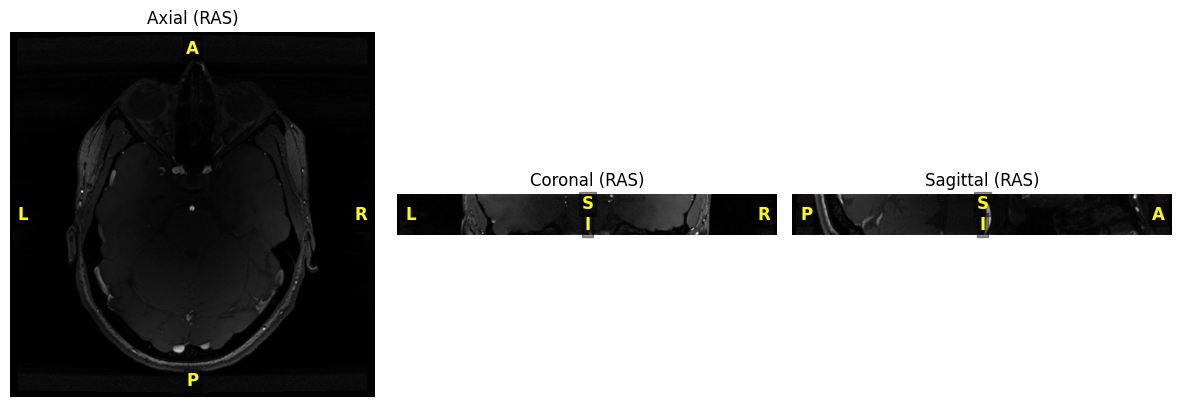

In [12]:
# Visualize NIfTI orientation (3D/4D) with direction labels
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from nibabel.orientations import aff2axcodes, io_orientation
from nibabel.orientations import apply_orientation

# Path to the NIfTI file (adjust to your case)
# nifti_path = "../data/nifti_patients/006_20241218_3T/Magnitude_NoProto_WIP_pc3d1r3.nii.gz"
nifti_path = "../data/nifti_patients/003_20240422_7T/Magnitude_NoProto_WIP_fl3d1r3.nii.gz"


img = nib.load(nifti_path)
data = img.get_fdata()
affine = img.affine

# Axis codes (L/R, A/P, S/I) in data order
axcodes = aff2axcodes(affine)
print("Current orientation (data):", axcodes)
print("Original shape:", data.shape)

# Reorient to RAS (Right-Anterior-Superior) for consistent viewing
# This does not change the file on disk; it only creates a reoriented view
ornt = io_orientation(affine)
ras_ornt = nib.orientations.axcodes2ornt(("R", "A", "S"))
transform = nib.orientations.ornt_transform(ornt, ras_ornt)
data_ras = apply_orientation(data, transform)

# If 4D, select a timepoint (or average) for visualization
if data_ras.ndim == 4:
    t = data_ras.shape[3] // 2  # middle timepoint
    vol = data_ras[:, :, :, t]
    print("Showing t =", t)
else:
    vol = data_ras

def add_labels(ax, left, right, top, bottom):
    ax.text(0.02, 0.5, left, transform=ax.transAxes, va="center", ha="left",
            color="yellow", fontsize=12, fontweight="bold", bbox=dict(facecolor="black", alpha=0.4, pad=2))
    ax.text(0.98, 0.5, right, transform=ax.transAxes, va="center", ha="right",
            color="yellow", fontsize=12, fontweight="bold", bbox=dict(facecolor="black", alpha=0.4, pad=2))
    ax.text(0.5, 0.98, top, transform=ax.transAxes, va="top", ha="center",
            color="yellow", fontsize=12, fontweight="bold", bbox=dict(facecolor="black", alpha=0.4, pad=2))
    ax.text(0.5, 0.02, bottom, transform=ax.transAxes, va="bottom", ha="center",
            color="yellow", fontsize=12, fontweight="bold", bbox=dict(facecolor="black", alpha=0.4, pad=2))

# Central slices for each plane
z = vol.shape[2] // 2
y = vol.shape[1] // 2
x = vol.shape[0] // 2

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Axial: R/L (left-right), A/P (top-bottom) in RAS
axial = vol[:, :, z].T
axes[0].imshow(axial, cmap="gray", origin="lower")
axes[0].set_title("Axial (RAS)")
axes[0].axis("off")
add_labels(axes[0], left="L", right="R", top="A", bottom="P")

# Coronal: R/L (left-right), S/I (top-bottom) in RAS
coronal = vol[:, y, :].T
axes[1].imshow(coronal, cmap="gray", origin="lower")
axes[1].set_title("Coronal (RAS)")
axes[1].axis("off")
add_labels(axes[1], left="L", right="R", top="S", bottom="I")

# Sagittal: A/P (left-right), S/I (top-bottom) in RAS
sagittal = vol[x, :, :].T
axes[2].imshow(sagittal, cmap="gray", origin="lower")
axes[2].set_title("Sagittal (RAS)")
axes[2].axis("off")
add_labels(axes[2], left="P", right="A", top="S", bottom="I")

plt.tight_layout()
plt.show()

# In RAS: +X is Right, +Y is Anterior, +Z is Superior.

In [13]:
import nibabel as nib
from nibabel.orientations import aff2axcodes

def inspect_xforms(path):
    img = nib.load(path)
    hdr = img.header

    sform = img.get_sform()
    qform = img.get_qform()

    print("\n===", path, "===")
    print("shape:", img.shape)
    print("sform_code:", int(hdr["sform_code"]), " qform_code:", int(hdr["qform_code"]))
    print("affine (chosen by nibabel) axcodes:", aff2axcodes(img.affine))
    print("sform axcodes:", aff2axcodes(sform))
    print("qform axcodes:", aff2axcodes(qform))

inspect_xforms("../data/nifti_patients/006_20241218_3T/Magnitude_NoProto_WIP_pc3d1r3.nii.gz")
inspect_xforms("../data/nifti_patients/006_20241218_7T/Magnitude_NoProto_WIP_fl3d1r3.nii.gz")


=== ../data/nifti_patients/006_20241218_3T/Magnitude_NoProto_WIP_pc3d1r3.nii.gz ===
shape: (448, 448, 48, 12)
sform_code: 2  qform_code: 0
affine (chosen by nibabel) axcodes: ('R', 'A', 'S')
sform axcodes: ('R', 'A', 'S')
qform axcodes: ('R', 'A', 'S')

=== ../data/nifti_patients/006_20241218_7T/Magnitude_NoProto_WIP_fl3d1r3.nii.gz ===
shape: (448, 448, 48, 14)
sform_code: 2  qform_code: 0
affine (chosen by nibabel) axcodes: ('R', 'A', 'S')
sform axcodes: ('R', 'A', 'S')
qform axcodes: ('R', 'A', 'S')


In [14]:
import nibabel as nib
import numpy as np
from nibabel.orientations import aff2axcodes

def inspect_affine(path):
    img = nib.load(path)
    A = img.affine[:3,:3]
    det = np.linalg.det(A)
    print("\n===", path, "===")
    print("axcodes:", aff2axcodes(img.affine))
    print("det(affine[:3,:3]):", det)
    print("affine[:3,:3]:\n", A)
    # normaliza columnas para ver direction cosines “tipo ITK”
    cols = A / np.linalg.norm(A, axis=0, keepdims=True)
    print("dircos (cols normalized):\n", cols)

inspect_affine("../data/nifti_patients/006_20241218_3T/Magnitude_NoProto_WIP_pc3d1r3.nii.gz")
inspect_affine("../data/nifti_patients/006_20241218_7T/Magnitude_NoProto_WIP_fl3d1r3.nii.gz")


=== ../data/nifti_patients/006_20241218_3T/Magnitude_NoProto_WIP_pc3d1r3.nii.gz ===
axcodes: ('R', 'A', 'S')
det(affine[:3,:3]): 0.12499999842316209
affine[:3,:3]:
 [[ 0.49992195  0.00767883 -0.00436708]
 [-0.00809979  0.49710101 -0.05315049]
 [ 0.0035255   0.05321294  0.49714783]]
dircos (cols normalized):
 [[ 0.99984392  0.01535765 -0.00873417]
 [-0.01619959  0.99420203 -0.10630099]
 [ 0.00705099  0.10642588  0.99429564]]

=== ../data/nifti_patients/006_20241218_7T/Magnitude_NoProto_WIP_fl3d1r3.nii.gz ===
axcodes: ('R', 'A', 'S')
det(affine[:3,:3]): 0.12499950701266577
affine[:3,:3]:
 [[ 0.49905241  0.0296492   0.00822382]
 [-0.02921626  0.49854654 -0.02444866]
 [-0.00964972  0.02392188  0.49933222]]
dircos (cols normalized):
 [[ 0.99810479  0.0592984   0.01644771]
 [-0.05843252  0.99709311 -0.0488975 ]
 [-0.01929944  0.04784376  0.99866837]]


In [9]:
import nibabel as nib
import numpy as np
from nibabel.processing import resample_from_to

p3 = "../data/nifti_patients/006_20241218_3T/Magnitude_NoProto_WIP_pc3d1r3.nii.gz"
p7 = "../data/nifti_patients/006_20241218_7T/Magnitude_NoProto_WIP_fl3d1r3.nii.gz"

img3 = nib.load(p3)
img7 = nib.load(p7)

def get_vol(img):
    data = np.asanyarray(img.dataobj)
    if data.ndim == 4:
        # usa media temporal para estabilidad
        return data.mean(axis=3)
    return data

def ncc(a, b, eps=1e-8):
    a = a.astype(np.float32); b = b.astype(np.float32)
    a = (a - a.mean()) / (a.std() + eps)
    b = (b - b.mean()) / (b.std() + eps)
    return float((a*b).mean())

def flip_nifti(img, axis):
    data = np.asanyarray(img.dataobj)
    data_f = np.flip(data, axis=axis)

    # Actualiza affine de forma correcta:
    # affine' = affine @ F, donde F invierte el eje y desplaza N-1
    N = data.shape[axis]
    F = np.eye(4)
    F[axis, axis] = -1
    F[axis, 3] = N - 1
    aff_f = img.affine @ F

    hdr = img.header.copy()
    out = nib.Nifti1Image(data_f, aff_f, header=hdr)

    # Copia sform/qform para que viewers no “improvisen”
    out.set_sform(aff_f, code=int(img.get_sform(coded=True)[1] or 1))
    out.set_qform(aff_f, code=int(img.get_qform(coded=True)[1] or 1))
    return out

# referencia = 7T
ref = img7
ref_vol = get_vol(ref)

def score(mov_img):
    mov_r = resample_from_to(mov_img, ref, order=1)
    mov_vol = get_vol(mov_r)
    # recorte opcional si hay mucho fondo; aquí simple:
    return ncc(ref_vol, mov_vol)

candidates = {"none": img3}
for ax, name in [(0,"flipX"), (1,"flipY"), (2,"flipZ")]:
    candidates[name] = flip_nifti(img3, axis=ax)

scores = {k: score(v) for k, v in candidates.items()}
best = max(scores, key=scores.get)

print("NCC scores:", scores)
print("BEST:", best, "->", scores[best])

# guarda el mejor si no es "none"
if best != "none":
    out_path = p3.replace(".nii.gz", f"__{best}_fixed.nii.gz")
    nib.save(candidates[best], out_path)
    print("Saved:", out_path)

NCC scores: {'none': 0.0, 'flipX': 0.0, 'flipY': 0.0, 'flipZ': 0.0}
BEST: none -> 0.0


Current orientation (data): ('R', 'A', 'S')
Showing t = 6


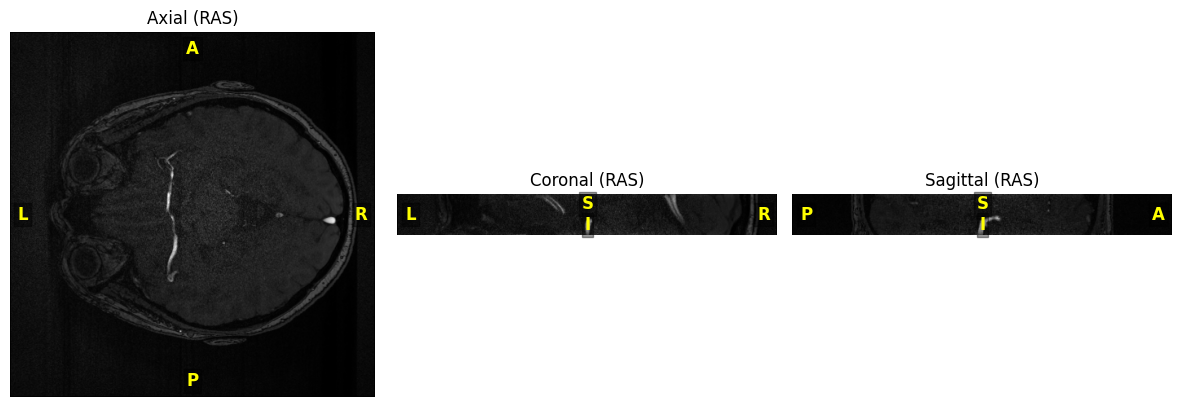

In [15]:
# Reorient LAS to RAS for visualization (with labels)
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from nibabel.orientations import aff2axcodes, io_orientation
from nibabel.orientations import apply_orientation

# Path to the NIfTI file (adjust to your case)
nifti_path = "../data/nifti_patients/006_20241218_3T/Magnitude_NoProto_WIP_pc3d1r3.nii.gz"

img = nib.load(nifti_path)
data = img.get_fdata()
affine = img.affine

print("Current orientation (data):", aff2axcodes(affine))

# Force reorient to RAS for display
ornt = io_orientation(affine)
ras_ornt = nib.orientations.axcodes2ornt(("R", "A", "S"))
transform = nib.orientations.ornt_transform(ornt, ras_ornt)
data_ras = apply_orientation(data, transform)

# If 4D, pick a timepoint
if data_ras.ndim == 4:
    t = data_ras.shape[3] // 2
    vol = data_ras[:, :, :, t]
    print("Showing t =", t)
else:
    vol = data_ras

def add_labels(ax, left, right, top, bottom):
    ax.text(0.02, 0.5, left, transform=ax.transAxes, va="center", ha="left",
            color="yellow", fontsize=12, fontweight="bold", bbox=dict(facecolor="black", alpha=0.4, pad=2))
    ax.text(0.98, 0.5, right, transform=ax.transAxes, va="center", ha="right",
            color="yellow", fontsize=12, fontweight="bold", bbox=dict(facecolor="black", alpha=0.4, pad=2))
    ax.text(0.5, 0.98, top, transform=ax.transAxes, va="top", ha="center",
            color="yellow", fontsize=12, fontweight="bold", bbox=dict(facecolor="black", alpha=0.4, pad=2))
    ax.text(0.5, 0.02, bottom, transform=ax.transAxes, va="bottom", ha="center",
            color="yellow", fontsize=12, fontweight="bold", bbox=dict(facecolor="black", alpha=0.4, pad=2))

# Central slices
z = vol.shape[2] // 2
y = vol.shape[1] // 2
x = vol.shape[0] // 2

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axial = vol[:, :, z].T
axes[0].imshow(axial, cmap="gray", origin="lower")
axes[0].set_title("Axial (RAS)")
axes[0].axis("off")
add_labels(axes[0], left="L", right="R", top="A", bottom="P")

coronal = vol[:, y, :].T
axes[1].imshow(coronal, cmap="gray", origin="lower")
axes[1].set_title("Coronal (RAS)")
axes[1].axis("off")
add_labels(axes[1], left="L", right="R", top="S", bottom="I")

sagittal = vol[x, :, :].T
axes[2].imshow(sagittal, cmap="gray", origin="lower")
axes[2].set_title("Sagittal (RAS)")
axes[2].axis("off")
add_labels(axes[2], left="P", right="A", top="S", bottom="I")

plt.tight_layout()
plt.show()

# Note: aff2axcodes prints header orientation (still LAS),
# but the displayed views are reoriented to RAS.

In [1]:
import nibabel as nib
import numpy as np

p = "../data/nifti_patients/006_20241218_3T/Magnitude_NoProto_WIP_pc3d1r3.nii.gz"
img = nib.load(p)

print("shape:", img.shape)
print("axcodes:", nib.aff2axcodes(img.affine))
print("qform_code:", img.header['qform_code'], "sform_code:", img.header['sform_code'])
print("qform:\n", img.get_qform())
print("sform:\n", img.get_sform())
print("affine:\n", img.affine)

shape: (448, 448, 48, 12)
axcodes: ('R', 'A', 'S')
qform_code: 1 sform_code: 1
qform:
 [[ 4.99921955e-01  7.67901460e-03  4.36710924e-03 -1.11583664e+02]
 [-8.09998459e-03  4.97101005e-01  5.31505498e-02 -9.77913132e+01]
 [-3.52550109e-03 -5.32130006e-02  4.97147812e-01 -5.21514177e-01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
sform:
 [[ 4.99921948e-01  7.67900003e-03  4.36710939e-03 -1.11583664e+02]
 [-8.09999928e-03  4.97101009e-01  5.31505495e-02 -9.77913132e+01]
 [-3.52549972e-03 -5.32130003e-02  4.97147799e-01 -5.21514177e-01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
affine:
 [[ 4.99921948e-01  7.67900003e-03  4.36710939e-03 -1.11583664e+02]
 [-8.09999928e-03  4.97101009e-01  5.31505495e-02 -9.77913132e+01]
 [-3.52549972e-03 -5.32130003e-02  4.97147799e-01 -5.21514177e-01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


In [2]:
import nibabel as nib
import numpy as np

p = "../data/nifti_patients/006_20241218_7T/Magnitude_NoProto_WIP_fl3d1r3.nii.gz"
img = nib.load(p)


print("shape:", img.shape)
print("axcodes:", nib.aff2axcodes(img.affine))
print("qform_code:", img.header['qform_code'], "sform_code:", img.header['sform_code'])
print("qform:\n", img.get_qform())
print("sform:\n", img.get_sform())
print("affine:\n", img.affine)

shape: (448, 448, 48, 14)
axcodes: ('R', 'A', 'S')
qform_code: 1 sform_code: 1
qform:
 [[ 4.99052395e-01  2.96491994e-02  8.22382090e-03 -1.18427406e+02]
 [-2.92162593e-02  4.98546526e-01 -2.44486569e-02 -1.12138832e+02]
 [-9.64971944e-03  2.39218757e-02  4.99332219e-01 -4.94922409e+01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
sform:
 [[ 4.99052405e-01  2.96491999e-02  8.22382141e-03 -1.18427406e+02]
 [-2.92162597e-02  4.98546541e-01 -2.44486555e-02 -1.12138832e+02]
 [-9.64972004e-03  2.39218771e-02  4.99332219e-01 -4.94922409e+01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
affine:
 [[ 4.99052405e-01  2.96491999e-02  8.22382141e-03 -1.18427406e+02]
 [-2.92162597e-02  4.98546541e-01 -2.44486555e-02 -1.12138832e+02]
 [-9.64972004e-03  2.39218771e-02  4.99332219e-01 -4.94922409e+01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


In [5]:
import numpy as np
import nibabel as nib

img = nib.load("../data/processed_inputs/001_20240313_7T/input_mag_raw.nii.gz")
M = img.affine[:3,:3]

# Direcciones físicas (world) de +i, +j, +k voxel
e_i = M[:,0] / (np.linalg.norm(M[:,0]) + 1e-12)
e_j = M[:,1] / (np.linalg.norm(M[:,1]) + 1e-12)
e_k = M[:,2] / (np.linalg.norm(M[:,2]) + 1e-12)

print("e_i (world dir of +i):", e_i)
print("e_j (world dir of +j):", e_j)
print("e_k (world dir of +k):", e_k)
print("axcodes:", nib.aff2axcodes(img.affine))

e_i (world dir of +i): [ 0.99940227  0.0127     -0.03215301]
e_j (world dir of +j): [-0.011862    0.99958789  0.026141  ]
e_k (world dir of +k): [ 0.03247175 -0.02574397  0.99914105]
axcodes: ('R', 'A', 'S')


In [11]:
#Check range of values in a NIfTI file
import nibabel as nib
import numpy as np

mag = nib.load("../data/processed_inputs/001_20240313_7T/input_mag_raw.nii.gz")
mag_data = np.asanyarray(mag.dataobj)
print("Min value:", mag_data.min())
print("Max value:", mag_data.max())
print("Mean value:", mag_data.mean())
print("Std value:", mag_data.std())

vx = nib.load("../data/processed_inputs/001_20240313_7T/Vx.nii.gz")
vx_data = np.asanyarray(vx.dataobj)
print("Vx Min value:", vx_data.min())
print("Vx Max value:", vx_data.max())
print("Vx Mean value:", vx_data.mean())
print("Vx Std value:", vx_data.std())

vy = nib.load("../data/processed_inputs/001_20240313_7T/Vy.nii.gz")
vy_data = np.asanyarray(vy.dataobj)
print("Vy Min value:", vy_data.min())
print("Vy Max value:", vy_data.max())
print("Vy Mean value:", vy_data.mean())
print("Vy Std value:", vy_data.std())

vz = nib.load("../data/processed_inputs/001_20240313_7T/Vz.nii.gz")
vz_data = np.asanyarray(vz.dataobj)
print("Vz Min value:", vz_data.min())
print("Vz Max value:", vz_data.max())
print("Vz Mean value:", vz_data.mean())
print("Vz Std value:", vz_data.std())

Min value: 0.0
Max value: 3322.0
Mean value: 108.07799
Std value: 131.3409
Vx Min value: -4095.0
Vx Max value: -0.0
Vx Mean value: -2019.8328
Vx Std value: 689.88934
Vy Min value: -4095.0
Vy Max value: -0.0
Vy Mean value: -2100.0286
Vy Std value: 708.8704
Vz Min value: 0.0
Vz Max value: 4095.0
Vz Mean value: 2077.709
Vz Std value: 725.9947
